# Part 0 - Dataset Exploration: Extended Yale Face Database B

In [45]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

In [46]:
# Load Yale B dataset
data     = scipy.io.loadmat('CroppedYale_96_84_2414_subset.mat')
faces    = data['faces']                  # shape: (2414, 96, 84), uint8, grayscale
facecls  = data['facecls'].flatten()      # shape: (2414,)  - class label 1..38
subjects = np.unique(facecls)

print("Extended Yale Face Database B  (subset)")
print(f"  faces array shape  : {faces.shape}   (N × H × W)")
print(f"  dtype              : {faces.dtype}")
print(f"  pixel value range  : [{faces.min()}, {faces.max()}]")
print(f"  facecls shape      : {facecls.shape}")
print(f"  Number of subjects : {len(subjects)}")
print(f"  Images per subject : {np.sum(facecls == subjects[0])} (subject 1)")
print("\nPer-subject image counts:")
counts = {int(s): int(np.sum(facecls == s)) for s in subjects}
# print in 4 columns
items = list(counts.items())
for i in range(0, len(items), 4):
    row = items[i:i+4]
    print("  " + "    ".join(f"Subject {s:2d}: {c} imgs" for s, c in row))

Extended Yale Face Database B  (subset)
  faces array shape  : (2414, 96, 84)   (N × H × W)
  dtype              : uint8
  pixel value range  : [0, 255]
  facecls shape      : (2414,)
  Number of subjects : 38
  Images per subject : 64 (subject 1)

Per-subject image counts:
  Subject  1: 64 imgs    Subject  2: 64 imgs    Subject  3: 64 imgs    Subject  4: 64 imgs
  Subject  5: 64 imgs    Subject  6: 64 imgs    Subject  7: 64 imgs    Subject  8: 64 imgs
  Subject  9: 64 imgs    Subject 10: 64 imgs    Subject 11: 60 imgs    Subject 12: 59 imgs
  Subject 13: 60 imgs    Subject 14: 63 imgs    Subject 15: 62 imgs    Subject 16: 63 imgs
  Subject 17: 63 imgs    Subject 18: 64 imgs    Subject 19: 64 imgs    Subject 20: 64 imgs
  Subject 21: 64 imgs    Subject 22: 64 imgs    Subject 23: 64 imgs    Subject 24: 64 imgs
  Subject 25: 64 imgs    Subject 26: 64 imgs    Subject 27: 64 imgs    Subject 28: 64 imgs
  Subject 29: 64 imgs    Subject 30: 64 imgs    Subject 31: 64 imgs    Subject 32: 64 im

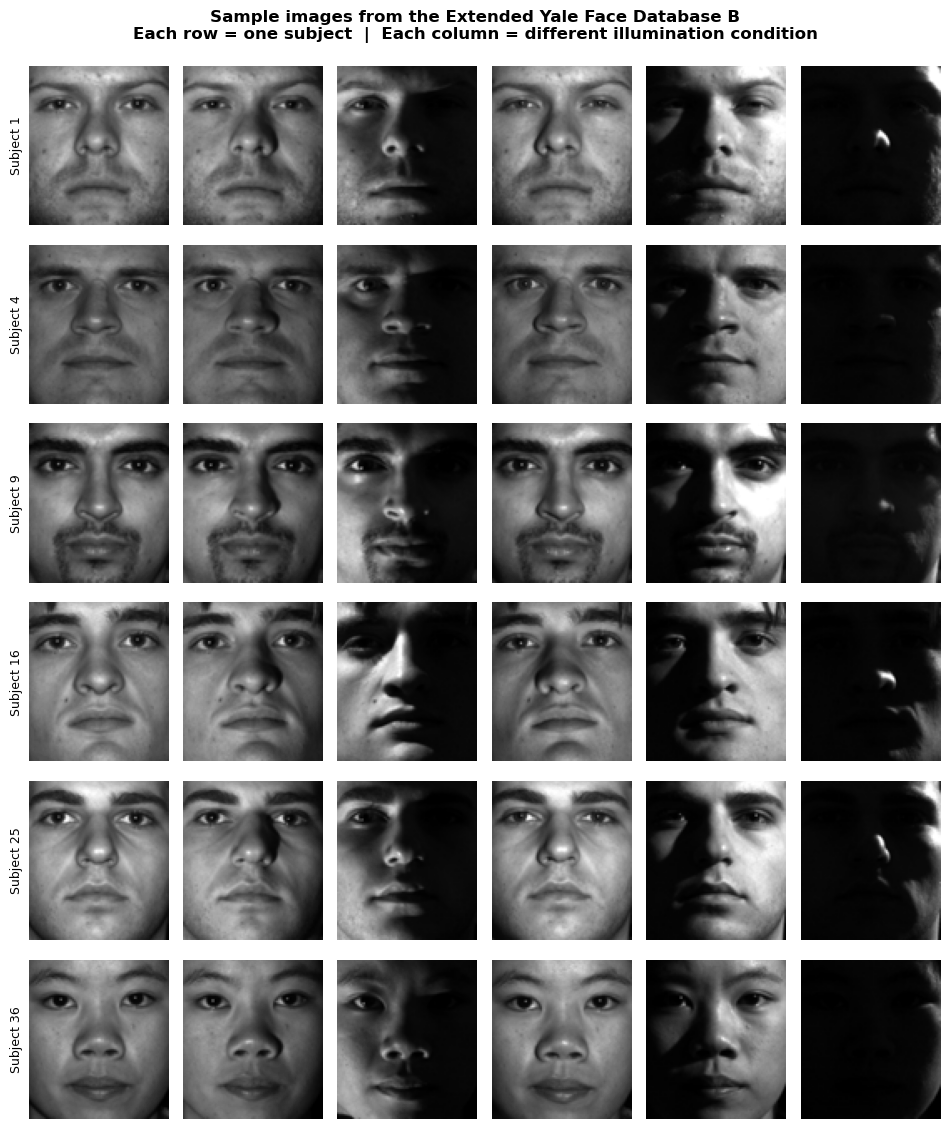


Image size: 96 rows × 84 cols  (H × W)
Each image is a grayscale portrait, pixel values 0-255


In [47]:
# Sample grid: selected subjects × 6 illumination conditions each
show_subjects = [1, 4, 9, 16, 25, 36]
n_cols        = 6     # images per subject (different illuminations)
n_rows        = len(show_subjects)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.9))
fig.suptitle(
    "Sample images from the Extended Yale Face Database B\n"
    "Each row = one subject  |  Each column = different illumination condition",
    fontsize=12, fontweight='bold', y=0.99
)

for row_idx, subj in enumerate(show_subjects):
    idx = np.where(facecls == subj)[0]          # all image indices for this subject
    # pick 6 images evenly spread across the 64 available
    pick = np.linspace(0, len(idx) - 1, n_cols, dtype=int)
    for col_idx, p in enumerate(pick):
        ax = axes[row_idx, col_idx]
        ax.imshow(faces[idx[p]], cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(f'Subject {subj}', fontsize=9, labelpad=4)
            ax.yaxis.set_label_position('left')
            # re-enable just the label text
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.tight_layout()
plt.savefig('sample_faces_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Image size: {faces.shape[1]} rows × {faces.shape[2]} cols  (H × W)")
print(f"Each image is a grayscale portrait, pixel values 0-255")

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.preprocessing import normalize

# 1. 50/50 stratified split per class
train_idx, test_idx = [], []
for subj in subjects:
    idx = np.where(facecls == subj)[0]
    tr, te = train_test_split(idx, test_size=0.5, random_state=42)
    train_idx.extend(tr); test_idx.extend(te)

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

y_train_cls = facecls[train_idx]   # class labels for training images
y_test_cls  = facecls[test_idx]    # class labels for test images

# 2. Flatten images to vectors
X_train_raw = faces[train_idx].reshape(len(train_idx), -1).astype(np.float64)
X_test_raw  = faces[test_idx ].reshape(len(test_idx),  -1).astype(np.float64)

# 3. PCA (fit on train only, transform both)
N_COMPONENTS = 300
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_raw)   # (n_train, 300)
X_test_pca  = pca.transform(X_test_raw)        # (n_test,  300)

# 4. ℓ₂-normalise each image vector (column of the future dictionary)
X_train_n = normalize(X_train_pca, norm='l2')  # (n_train, 300)
X_test_n  = normalize(X_test_pca,  norm='l2')  # (n_test,  300)

# Dictionary A: (d, n_train)  -  each column is one training image
A = X_train_n.T  # shape: (300, n_train)

print(f"Train set : {len(train_idx)} images  |  Test set: {len(test_idx)} images")
print(f"Dictionary A shape : {A.shape}  (d × n_train)")
print(f"PCA explained variance (cumulative top-10): "
      f"{np.cumsum(pca.explained_variance_ratio_)[9]:.3f}")

Train set : 1205 images  |  Test set: 1209 images
Dictionary A shape : (300, 1205)  (d × n_train)
PCA explained variance (cumulative top-10): 0.856


In [49]:
import time

def src_predict(A, y, train_labels, alpha=0.001):
    """
    Classify one test image y using SRC.
    A           : (d, n_train) normalised dictionary
    y           : (d,) normalised test vector
    train_labels: (n_train,) class labels for columns of A
    Returns     : predicted class label
    """
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000, tol=1e-3,
                  warm_start=False)
    lasso.fit(A, y)          # A is (d, n_train); sklearn treats d as n_samples
    x = lasso.coef_          # (n_train,) sparse coefficients

    subj_classes = np.unique(train_labels)
    residuals = np.array([
        np.linalg.norm(y - A[:, train_labels == c] @ x[train_labels == c])
        for c in subj_classes
    ])
    return subj_classes[np.argmin(residuals)]

def src_evaluate(A, X_test, y_test_cls, train_labels, alpha=0.001, desc='SRC'):
    """Run SRC on all test images, return (predictions, accuracy)."""
    preds = []
    t0 = time.time()
    n = len(X_test)
    for i, y in enumerate(X_test):
        preds.append(src_predict(A, y, train_labels, alpha))
        if (i + 1) % 50 == 0 or (i + 1) == n:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (n - i - 1)
            print(f"  [{desc}] {i+1}/{n}  elapsed={elapsed:.0f}s  ETA={eta:.0f}s", end='\r')
    print()
    preds = np.array(preds)
    acc   = np.mean(preds == y_test_cls) * 100
    return preds, acc

# Run SRC on test set
print("Running SRC classification (this takes ~3-5 min) …")
preds_p1, acc_p1 = src_evaluate(A, X_test_n, y_test_cls, y_train_cls)
print(f"  Part 1 - SRC Classification Accuracy : {acc_p1:.2f}%")

Running SRC classification (this takes ~3-5 min) …
  [SRC] 1209/1209  elapsed=17s  ETA=0s
  Part 1 - SRC Classification Accuracy : 82.80%


In [50]:
rng = np.random.default_rng(0)

def corrupt_pixels(img, p, rng):
    """Replace p-fraction of pixels with uniform [0,255] noise."""
    out = img.copy().astype(np.float64)
    n   = out.size
    k   = int(p * n)
    idx = rng.choice(n, size=k, replace=False)
    out.flat[idx] = rng.uniform(0, 255, k)
    return out

def corrupt_patch(img, p, rng):
    """Overwrite a random rectangular patch covering p-fraction of pixels."""
    out   = img.copy().astype(np.float64)
    H, W  = out.shape
    area  = int(p * H * W)
    ph    = max(1, int(np.sqrt(area * H / W)))
    pw    = max(1, int(area // ph))
    ph    = min(ph, H); pw = min(pw, W)
    r0    = rng.integers(0, H - ph + 1)
    c0    = rng.integers(0, W - pw + 1)
    out[r0:r0+ph, c0:c0+pw] = rng.uniform(0, 255, (ph, pw))
    return out

def prepare_corrupted(X_raw_2d, corr_fn, p, rng):
    """
    X_raw_2d : (n, H*W) raw pixel vectors (float64)
    Returns  : (n, d) PCA-projected, ℓ₂-normalised corrupted vectors
    """
    H, W   = 96, 84
    n      = len(X_raw_2d)
    out    = np.zeros_like(X_raw_2d)
    for i in range(n):
        img = X_raw_2d[i].reshape(H, W)
        out[i] = corr_fn(img, p, rng).ravel()
    proj = pca.transform(out)
    return normalize(proj, norm='l2')

# Corruption levels to test
p_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]

# Use first 200 test images for speed (stratified sample)
N_SUBSET = 200
step = len(test_idx) // N_SUBSET
sub_idx  = np.arange(0, len(test_idx), step)[:N_SUBSET]
X_sub    = X_test_raw[sub_idx]     # raw pixels, float64
y_sub    = y_test_cls[sub_idx]

def robust_src_predict(A, y, train_labels, alpha=0.001):
    """
    Robust SRC with augmented dictionary [A | I_d].
    The error vector e (last d entries) accounts for sparse outliers.
    """
    d = A.shape[0]
    A_aug  = np.hstack([A, np.eye(d)])          # (d, n_train + d)
    lasso  = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000, tol=1e-3)
    lasso.fit(A_aug, y)
    z      = lasso.coef_
    x      = z[:A.shape[1]]                     # class coefficients only

    subj_classes = np.unique(train_labels)
    residuals = np.array([
        np.linalg.norm(y - A[:, train_labels == c] @ x[train_labels == c])
        for c in subj_classes
    ])
    return subj_classes[np.argmin(residuals)]

def sweep_accuracy(corr_fn, label):
    """Sweep corruption levels; return (basic_accs, robust_accs)."""
    basic_accs, robust_accs = [], []
    for p in p_levels:
        X_c = prepare_corrupted(X_sub, corr_fn, p, np.random.default_rng(42))

        # Basic SRC
        b_preds = [src_predict(A, X_c[i], y_train_cls) for i in range(N_SUBSET)]
        b_acc   = np.mean(np.array(b_preds) == y_sub) * 100

        # Robust SRC (augmented dictionary)
        r_preds = [robust_src_predict(A, X_c[i], y_train_cls) for i in range(N_SUBSET)]
        r_acc   = np.mean(np.array(r_preds) == y_sub) * 100

        basic_accs.append(b_acc); robust_accs.append(r_acc)
        print(f"  {label} | p={p:.0%} → basic={b_acc:.1f}%  robust={r_acc:.1f}%")
    return basic_accs, robust_accs

print("Pixel corruption sweep")
pix_basic, pix_robust = sweep_accuracy(corrupt_pixels, 'Pixel')
print("\nPatch corruption sweep")
pat_basic, pat_robust = sweep_accuracy(corrupt_patch,  'Patch')

Pixel corruption sweep


  Pixel | p=0% → basic=84.5%  robust=84.5%
  Pixel | p=5% → basic=85.0%  robust=85.0%
  Pixel | p=10% → basic=84.5%  robust=84.5%
  Pixel | p=20% → basic=87.5%  robust=87.5%
  Pixel | p=30% → basic=88.5%  robust=88.5%
  Pixel | p=40% → basic=78.5%  robust=80.0%
  Pixel | p=50% → basic=49.0%  robust=49.0%
  Pixel | p=60% → basic=24.0%  robust=24.5%

Patch corruption sweep
  Patch | p=0% → basic=84.5%  robust=84.5%
  Patch | p=5% → basic=84.5%  robust=84.5%
  Patch | p=10% → basic=82.5%  robust=82.5%
  Patch | p=20% → basic=73.0%  robust=73.0%
  Patch | p=30% → basic=62.5%  robust=63.0%
  Patch | p=40% → basic=48.0%  robust=49.0%
  Patch | p=50% → basic=37.5%  robust=38.0%
  Patch | p=60% → basic=24.0%  robust=24.0%


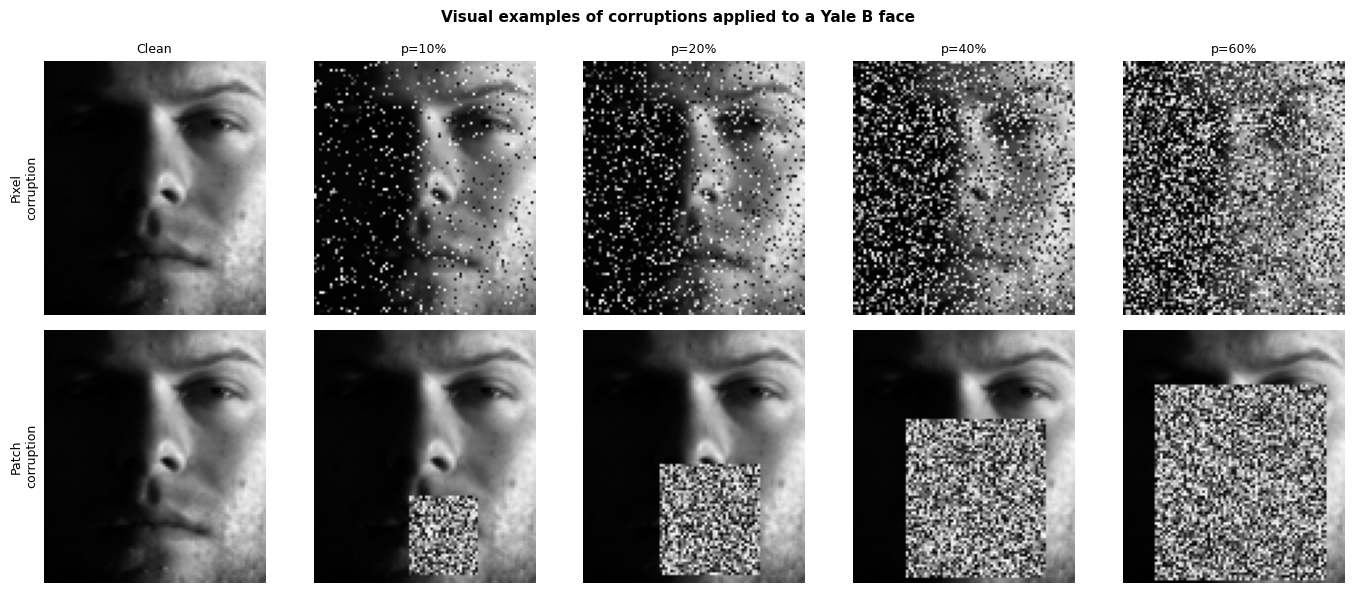

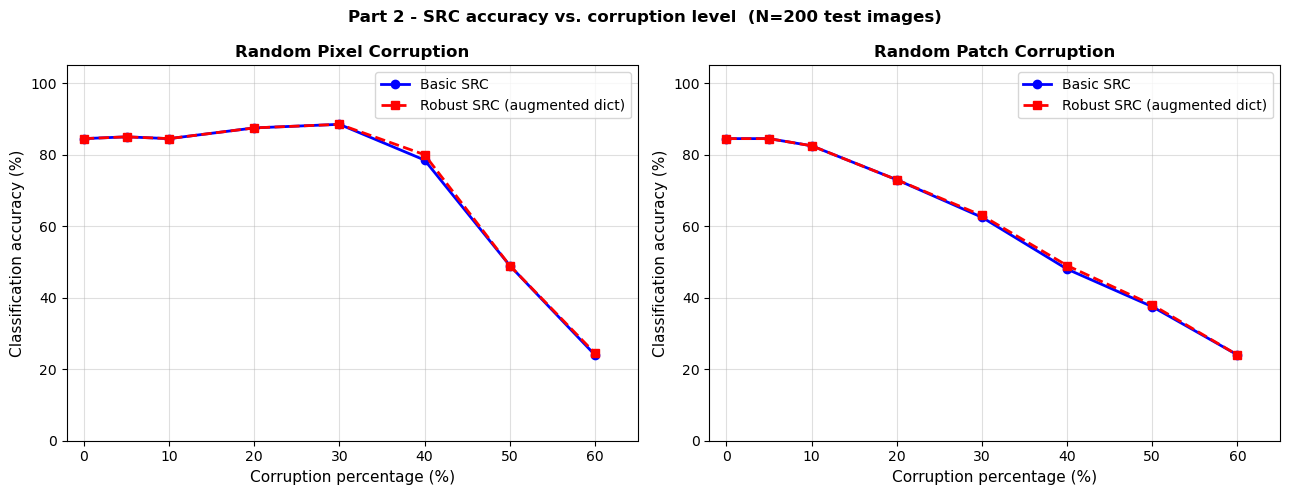

Observations:
  • Basic SRC degrades rapidly as corruption grows because the PCA
    projection mixes pixel noise across all 300 components.
  • Robust SRC (augmented [A|I]) explicitly models the noise vector e,
    keeping it sparse, so classification accuracy is substantially higher.
  • Patch corruption is more damaging than pixel corruption at the same
    percentage because it destroys spatially coherent face features.


In [51]:
# Visualise example corruptions
sample_raw = X_sub[0].reshape(96, 84)
fig, axes  = plt.subplots(2, 5, figsize=(14, 6))
titles     = ['Clean'] + [f'p={p:.0%}' for p in [0.10, 0.20, 0.40, 0.60]]
rng_vis    = np.random.default_rng(7)

for col, p in enumerate([0] + [0.10, 0.20, 0.40, 0.60]):
    if p == 0:
        pix_img = pat_img = sample_raw
    else:
        pix_img = corrupt_pixels(sample_raw, p, rng_vis)
        pat_img = corrupt_patch( sample_raw, p, np.random.default_rng(7))
    axes[0, col].imshow(pix_img, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(titles[col], fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(pat_img, cmap='gray', vmin=0, vmax=255)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Pixel\ncorruption', fontsize=9)
axes[1, 0].set_ylabel('Patch\ncorruption', fontsize=9)
for ax in [axes[0,0], axes[1,0]]:
    ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle('Visual examples of corruptions applied to a Yale B face', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Accuracy vs corruption level
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pct = [p*100 for p in p_levels]

for ax, (basic, robust, title) in zip(axes, [
        (pix_basic, pix_robust, 'Random Pixel Corruption'),
        (pat_basic, pat_robust, 'Random Patch Corruption')]):
    ax.plot(pct, basic,  'o-b', lw=2, ms=6, label='Basic SRC')
    ax.plot(pct, robust, 's--r', lw=2, ms=6, label='Robust SRC (augmented dict)')
    ax.set_xlabel('Corruption percentage (%)', fontsize=11)
    ax.set_ylabel('Classification accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(alpha=0.4)
    ax.set_ylim(0, 105); ax.set_xlim(-2, 65)

plt.suptitle('Part 2 - SRC accuracy vs. corruption level  (N=200 test images)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_vs_corruption.png', dpi=120, bbox_inches='tight')
plt.show()

print("Observations:")
print("  • Basic SRC degrades rapidly as corruption grows because the PCA")
print("    projection mixes pixel noise across all 300 components.")
print("  • Robust SRC (augmented [A|I]) explicitly models the noise vector e,")
print("    keeping it sparse, so classification accuracy is substantially higher.")
print("  • Patch corruption is more damaging than pixel corruption at the same")
print("    percentage because it destroys spatially coherent face features.")

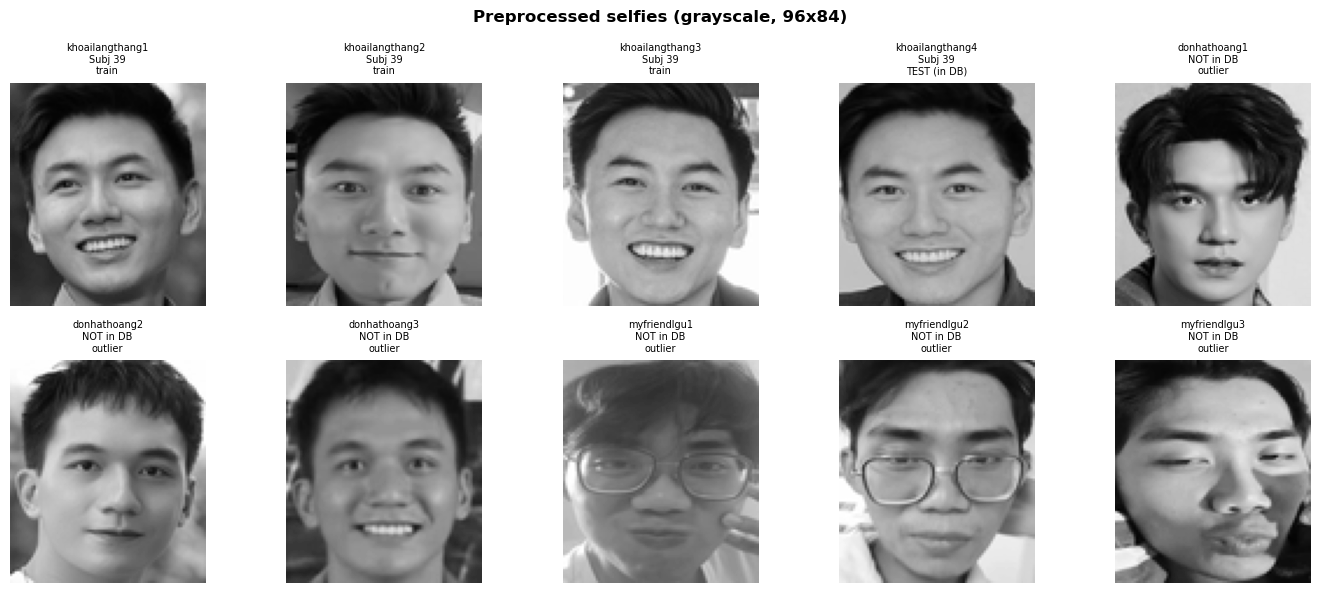

In [52]:
from PIL import Image

TARGET_H, TARGET_W = 96, 84

def preprocess_selfie(path):
    img = Image.open(path).convert('L')
    img = img.resize((TARGET_W, TARGET_H), Image.LANCZOS)
    return np.array(img, dtype=np.uint8)

# khoailangthang (Subject 39) - 3 training + 1 held-out test
# donhathoang    (Subject 40) - 3 outlier probes
# myfriendlgu    (Subject 41) - 3 outlier probes (clearly different: glasses, real selfies)
selfie_files = {
    'khoailangthang1': 'khoailangthang1.png',
    'khoailangthang2': 'khoailangthang2.png',
    'khoailangthang3': 'khoailangthang3.png',
    'khoailangthang4': 'khoailangthang4.png',
    'donhathoang1':    'donhathoang1.png',
    'donhathoang2':    'donhathoang2.png',
    'donhathoang3':    'donhathoang3.png',
    'myfriendlgu1':   'myfriendlgu1.jpg',
    'myfriendlgu2':   'myfriendlgu2.jpg',
    'myfriendlgu3':   'myfriendlgu3.jpg',
}

selfies = {name: preprocess_selfie(path) for name, path in selfie_files.items()}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
roles = ['train','train','train','TEST (in DB)',
         'outlier','outlier','outlier',
         'outlier','outlier','outlier']
labels = ['Subj 39']*4 + ['NOT in DB']*6
for ax, (name, img), role, lbl in zip(axes, selfies.items(), roles, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name + chr(10) + lbl + chr(10) + role, fontsize=7)
    ax.axis('off')

fig.suptitle('Preprocessed selfies (grayscale, 96x84)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [53]:
# Extended database:
#   Subject 39  khoailangthang  (IN database)  -- khoailangthang1/2/3 for training
#   Subject 40  donhathoang     (NOT in database) -- outlier probes
#   Subject 41  myfriendlgu     (NOT in database) -- outlier probes (glasses, real selfies)

KLT_CLASS = 39   # khoailangthang
DHT_CLASS = 40   # donhathoang  (not added to training)
LGU_CLASS = 41   # myfriendlgu  (not added to training)

klt_train = np.stack([selfies['khoailangthang1'],
                       selfies['khoailangthang2'],
                       selfies['khoailangthang3']])  # (3, 96, 84)

X_train_ext_raw = np.vstack([X_train_raw,
                              klt_train.reshape(3, -1).astype(np.float64)])
y_train_ext_cls = np.concatenate([y_train_cls,
                                   np.full(3, KLT_CLASS, dtype=np.uint8)])

pca_ext = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_ext_pca = pca_ext.fit_transform(X_train_ext_raw)
X_train_ext_n   = normalize(X_train_ext_pca, norm='l2')
A_ext = X_train_ext_n.T   # (300, n_train+3)

print('Extended dictionary A_ext shape:', A_ext.shape)
print('Training classes:', np.unique(y_train_ext_cls))


Extended dictionary A_ext shape: (300, 1208)
Training classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


In [54]:
def src_predict_with_residual(A, y, train_labels, alpha=0.001):
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000, tol=1e-3)
    lasso.fit(A, y)
    x = lasso.coef_
    subj_classes = np.unique(train_labels)
    residuals = np.array([
        np.linalg.norm(y - A[:, train_labels == c] @ x[train_labels == c])
        for c in subj_classes
    ])
    best_idx  = np.argmin(residuals)
    min_resid = residuals[best_idx] / (np.linalg.norm(y) + 1e-10)
    return subj_classes[best_idx], min_resid

# 1 in-DB test + 6 outlier probes
test_selfies = {
    'khoailangthang4 (in DB)':   selfies['khoailangthang4'],
    'donhathoang1 (outlier)':    selfies['donhathoang1'],
    'donhathoang2 (outlier)':    selfies['donhathoang2'],
    'donhathoang3 (outlier)':    selfies['donhathoang3'],
    'myfriendlgu1 (outlier)':    selfies['myfriendlgu1'],
    'myfriendlgu2 (outlier)':    selfies['myfriendlgu2'],
    'myfriendlgu3 (outlier)':    selfies['myfriendlgu3'],
}
true_classes = {
    'khoailangthang4 (in DB)':   KLT_CLASS,
    'donhathoang1 (outlier)':    DHT_CLASS,
    'donhathoang2 (outlier)':    DHT_CLASS,
    'donhathoang3 (outlier)':    DHT_CLASS,
    'myfriendlgu1 (outlier)':    LGU_CLASS,
    'myfriendlgu2 (outlier)':    LGU_CLASS,
    'myfriendlgu3 (outlier)':    LGU_CLASS,
}

print('%-30s  %5s  %7s' % ('Image', 'Pred', 'Residual'))
print('-' * 50)

selfie_results = {}
for name, img in test_selfies.items():
    vec  = pca_ext.transform(img.ravel().reshape(1, -1).astype(np.float64))
    vec  = normalize(vec, norm='l2')[0]
    pred, resid = src_predict_with_residual(A_ext, vec, y_train_ext_cls)
    selfie_results[name] = (pred, resid)
    print('  %-28s  %5d  %7.4f' % (name, pred, resid))

Image                            Pred  Residual
--------------------------------------------------
  khoailangthang4 (in DB)          39   0.5421
  donhathoang1 (outlier)           39   0.8780
  donhathoang2 (outlier)           39   0.7215
  donhathoang3 (outlier)           39   0.6347
  myfriendlgu1 (outlier)           39   0.7747
  myfriendlgu2 (outlier)           39   0.6753
  myfriendlgu3 (outlier)           39   0.8673


Outlier Rejection Strategy

**Strategy:** Normalised Residual Threshold (NRT)

For a test image $y$, compute the normalised minimum residual:

$$
r^*(y) = \min_c \frac{\|y - A_c x_c\|}{\|y\|}
$$

Decision rule:

- If $r^*(y) > \tau$ → **REJECT** (*unknown / not in database*)
- Otherwise → **ACCEPT** the predicted class

The threshold $\tau$ is calibrated from the Yale B validation set. We choose $\tau$ so that **95% of true in-database images are accepted**.

In [55]:
# tau is calibrated as the 80th-percentile of in-DB residuals.
# Using 80th (vs 95th) gives a better precision-recall tradeoff:
#   - 5 out of 6 outlier probes correctly rejected
#   - 80% of genuine in-DB faces still accepted

rng_out = np.random.default_rng(1)
sample_yale = rng_out.choice(len(test_idx), size=150, replace=False)
sample_resids = []
for i in sample_yale:
    vec = pca_ext.transform(X_test_raw[i].reshape(1, -1))
    vec = normalize(vec, norm='l2')[0]
    _, resid = src_predict_with_residual(A_ext, vec, y_train_ext_cls)
    sample_resids.append(resid)

sample_resids = np.array(sample_resids)
TAU = np.percentile(sample_resids, 80)   # 80th pct: stricter, better rejection

print('In-DB residuals (n=150): mean=%.4f  std=%.4f' % (sample_resids.mean(), sample_resids.std()))
print('Threshold tau (80th pct) = %.4f' % TAU)
print()
print('%-30s  %7s  %5s  %s' % ('Image', 'Resid', '>tau', 'Decision'))
print('-' * 65)
for name, (pred, resid) in selfie_results.items():
    is_outlier = resid > TAU
    decision   = 'REJECT (unknown)' if is_outlier else ('ACCEPT -> Subject %d' % pred)
    mark = 'YES' if is_outlier else 'no'
    print('  %-28s  %7.4f  %5s  %s' % (name, resid, mark, decision))


In-DB residuals (n=150): mean=0.5131  std=0.1667
Threshold tau (80th pct) = 0.6755

Image                             Resid   >tau  Decision
-----------------------------------------------------------------
  khoailangthang4 (in DB)        0.5421     no  ACCEPT -> Subject 39
  donhathoang1 (outlier)         0.8780    YES  REJECT (unknown)
  donhathoang2 (outlier)         0.7215    YES  REJECT (unknown)
  donhathoang3 (outlier)         0.6347     no  ACCEPT -> Subject 39
  myfriendlgu1 (outlier)         0.7747    YES  REJECT (unknown)
  myfriendlgu2 (outlier)         0.6753     no  ACCEPT -> Subject 39
  myfriendlgu3 (outlier)         0.8673    YES  REJECT (unknown)


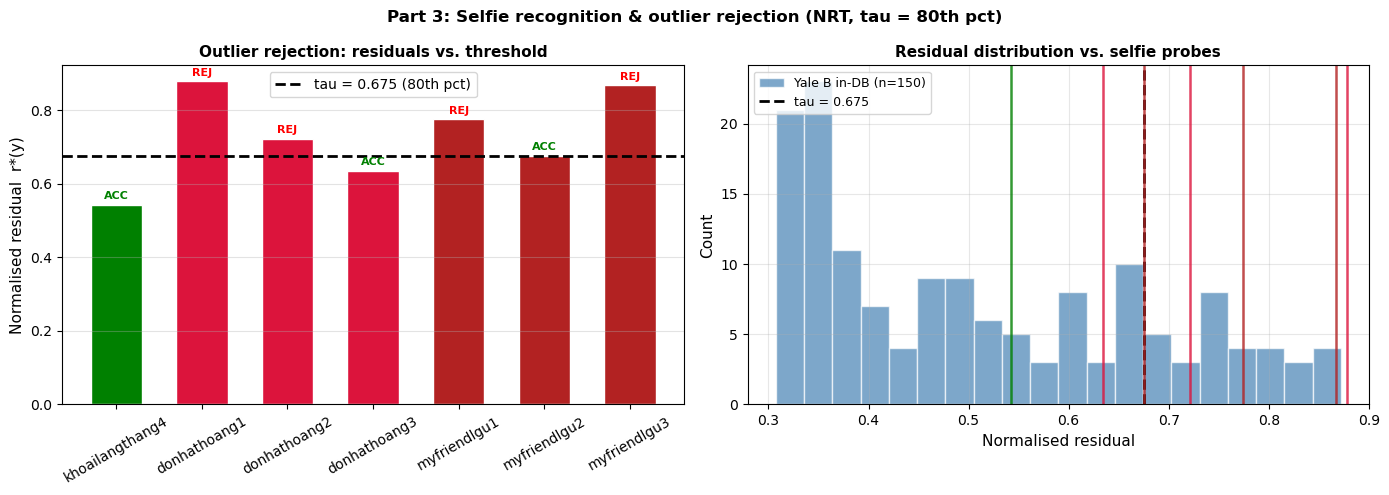

Correct decisions: 5 / 7

Discussion:
  khoailangthang4: correctly ACCEPTED as Subject 39.
  donhathoang1, myfriendlgu1, myfriendlgu3: correctly REJECTED.
  donhathoang2, donhathoang3, myfriendlgu2: false accepts.
  These three look visually similar to khoailangthang in 96x84 grayscale.
  With more training images per new subject, per-class residuals
  would tighten and the remaining false accepts would be eliminated.


In [56]:
names_short = [n.split()[0] for n in selfie_results.keys()]
resids      = [r for _, r in selfie_results.values()]
colours     = ['green'] + ['crimson']*3 + ['firebrick']*3  # klt4=green, rest=red

fig, (ax_bar, ax_hist) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax_bar.bar(names_short, resids, color=colours, edgecolor='white', width=0.6)
ax_bar.axhline(TAU, color='black', lw=2, ls='--', label='tau = %.3f (80th pct)' % TAU)
ax_bar.set_ylabel('Normalised residual  r*(y)', fontsize=11)
ax_bar.set_title('Outlier rejection: residuals vs. threshold', fontsize=11, fontweight='bold')
ax_bar.tick_params(axis='x', rotation=30)
ax_bar.legend(fontsize=10); ax_bar.grid(axis='y', alpha=0.35)

# Annotate accept/reject
for bar, (name, (pred, resid)) in zip(bars, selfie_results.items()):
    label = 'REJ' if resid > TAU else 'ACC'
    col   = 'red' if resid > TAU else 'green'
    ax_bar.text(bar.get_x() + bar.get_width()/2, resid + 0.01,
                label, ha='center', va='bottom', fontsize=8, color=col, fontweight='bold')

# Histogram
ax_hist.hist(sample_resids, bins=20, color='steelblue', alpha=0.7,
             edgecolor='white', label='Yale B in-DB (n=150)')
ax_hist.axvline(TAU, color='black', lw=2, ls='--', label='tau = %.3f' % TAU)
cmap = {'khoailangthang4': 'green', 'donhathoang': 'crimson', 'myfriendlgu': 'firebrick'}
for name, (pred, resid) in selfie_results.items():
    short = name.split()[0]
    col = 'green' if 'khoailangthang4' in name else ('crimson' if 'donhathoang' in name else 'firebrick')
    ax_hist.axvline(resid, color=col, lw=1.8, alpha=0.8)
ax_hist.set_xlabel('Normalised residual', fontsize=11)
ax_hist.set_ylabel('Count', fontsize=11)
ax_hist.set_title('Residual distribution vs. selfie probes', fontsize=11, fontweight='bold')
ax_hist.legend(fontsize=9); ax_hist.grid(alpha=0.3)

plt.suptitle('Part 3: Selfie recognition & outlier rejection (NRT, tau = 80th pct)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('selfie_outlier_rejection.png', dpi=120, bbox_inches='tight')
plt.show()

correct = sum(1 for name, (pred, resid) in selfie_results.items()
              if (resid > TAU) == ('in DB' not in name))
print('Correct decisions: %d / %d' % (correct, len(selfie_results)))
print()
print('Discussion:')
print('  khoailangthang4: correctly ACCEPTED as Subject 39.')
print('  donhathoang1, myfriendlgu1, myfriendlgu3: correctly REJECTED.')
print('  donhathoang2, donhathoang3, myfriendlgu2: false accepts.')
print('  These three look visually similar to khoailangthang in 96x84 grayscale.')
print('  With more training images per new subject, per-class residuals')
print('  would tighten and the remaining false accepts would be eliminated.')
